#### `This dataset is obtained from the Supplementary Material of the article Orbital-engineered anomalous Hall conductivity in stable full Heusler compounds: a pathway to optimized spintronics by Viet Q. Bui et al.`
https://doi.org/10.1039/d4tc02116a

In [1]:
##Import the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_error
import re

In [2]:
Descriptor = pd.read_csv("Elemental_Descriptor_Big_Validation_Data.csv")
Descriptor.rename(columns={'a(Å)': 'LatticeConstant'}, inplace=True)
Descriptor.head(2)

,ID,Compound,X,Y,Z,Structure,LatticeConstant,X2YZ,Element,Atomic-volume_1,Allen-EN_1,Atomic-volume_2,Allen-EN_2,Atomic-volume_3,Allen-EN_3
0,1687,Rh2MnGa,Rh,Mn,Ga,l21,6.040,True,Rh Mn Ga,8.298831,9.259,7.525759,10.34,11.797462,10.390
1,1738,Rh2PtAl,Rh,Pt,Al,l21,6.154,True,Rh Pt Al,8.298831,9.259,9.073674,10.16,9.993162,9.539


In [3]:
Descriptor.shape

(2587, 15)

In [4]:
ML_Model_Compound_List = ['Zr2NiGa', 'Co2ScGa', 'Co2ScSn', 'Co2TiSi', 'Co2TiGe', 'Co2HfSn', 'Co2NbAl', 'Co2YP', 'Co2YAs', 'Co2YSb', 'Co2YBi', 'Cr2CoSb', 'Cr2FeSb', 'Cr2NiSb', 'Co2RuGa', 'Fe2RuGa', 'Mn2RuGa', 'Cr2RuGa', 'V2RuGa', 'Ti2RuGa', 'Mn2CrAl', 'Mn2CrGa', 'Mn2CrSi', 'Mn2CrGe', 'Mn2CrSb', 'Mn2FeAl', 'Mn2FeGa', 'Mn2FeSi', 'Mn2FeGe', 'Mn2FeSb', 'Cr2CoAl', 'Cr2CoGa', 'Cr2CoIn', 'Cr2CoSi', 'Cr2CoGe', 'Cr2CoSn', 'Cr2CoSb', 'Cr2NiAl', 'Cr2NiGa', 'Cr2NiIn', 'Cr2NiSi', 'Cr2NiGe', 'Cr2NiSn', 'Cr2NiSb', 'Fe2MoGe', 'Fe2MoSb', 'Co2MoGe', 'Co2MoSb', 'Mn2PdV', 'Mn2NiV', 'Mn2AgV', 'Mn2AuV', 'Mn2CoV', 'Mn2PtV', 'Mn2IrV', 'V2CrSb', 'V2MnSb', 'V2FeSb', 'V2CoSb', 'Sc2VIn', 'Sc2VSi', 'Sc2VGe', 'Sc2VSn', 'Sc2CrAl', 'Sc2CrGa', 'Sc2CrIn', 'Sc2CrSi', 'Sc2CrGe', 'Sc2CrSn', 'Sc2MnSi', 'Sc2MnGe', 'Sc2MnSn', 'Ti2VSi', 'Ti2VGe', 'Ti2VSn', 'Sc2CoSi', 'Sc2CoGe', 'Sc2CoSn', 'Ti2MnSi', 'Ti2MnGe', 'Ti2MnSn', 'Ti2FeAl', 'Ti2FeGa', 'Ti2FeIn', 'Ti2FeSi', 'Ti2FeGe', 'Ti2FeSn', 'Ti2CoAl', 'Ti2CoGa', 'Ti2CoIn', 'V2CrGe', 'V2MnAl', 'V2MnGa', 'Ti2CoSi', 'Ti2CoGe', 'Ti2CoSn', 'Ti2NiAl', 'Ti2NiGa', 'Ti2NiIn', 'Cr2MnAl', 'Cr2NiAl', 'Cr2CoP', 'Mn2FeP', 'Mn2FeAs', 'Mn2CoP', 'Mn2CoAs', 'Mn2CuSi', 'Sc2VAl', 'Sc2VGa', 'Sc2MnAl', 'Sc2MnGa', 'Sc2MnIn', 'Sc2VSb', 'Ti2VAl', 'Ti2VGa', 'Sc2CrP', 'Sc2CrSb', 'Sc2FeAl', 'Sc2FeGa', 'Sc2FeIn', 'Ti2CrAl', 'Ti2CrGa', 'Ti2CrIn', 'Sc2MnSb', 'Ti2VP', 'Sc2NiAl', 'Sc2NiGa', 'Sc2NiIn', 'Ti2CrSb', 'Sc2CoSb', 'Ti2CrAs', 'Sc2NiSi', 'Sc2NiGe', 'Sc2NiSn', 'Ti2MnSb', 'Ti2FeAs', 'V2FeGa', 'Ti2NiSn', 'Ti2FeSb', 'V2FeAl', 'V2MnGe', 'V2MnSn', 'V2FeGe', 'Cr2MnGa', 'Cr2MnGe', 'V2CoSi', 'Cr2CoAl', 'Cr2CoSi', 'Cr2CoGe', 'Mn2FeAl', 'Mn2FeGa', 'Cr2NiSi', 'Cr2NiGe', 'Mn2FeSi', 'Mn2FeGe', 'Mn2CuP', 'Mn2RhAl', 'Mn2RhGa', 'Mn2RhIn', 'Mn2RhSi', 'Mn2RhGe', 'Hf2CoGa', 'Hf2CoIn', 'Mn2NiGa', 'Mn2NiIn', 'Mn2NiSn', 'Mn2NiSb', 'Mn2RuSi', 'Mn2RuGe', 'Mn2CoAl', 'Mn2CoGa', 'Mn2CoIn', 'Mn2CoSi', 'Mn2CoGe', 'Mn2CoSn', 'Mn2CoSb', 'Fe2NiAl', 'Fe2NiGa', 'Fe2NiSi', 'Fe2NiGe', 'Zr2RhAl', 'Zr2RhGa', 'Zr2RhIn', 'Cr2PtGa', 'Mn2PtGa', 'Fe2PtGa', 'Co2PtGa', 'Co2MnAl', 'Co2MnGe', 'Co2MnSi', 'Co2MnGa', 'Sc2CoAl', 'Sc2CoGa', 'Sc2CoIn', 'Co2TiPb', 'Co2MoPb', 'V2TiGa', 'V2TiGe', 'V2CrGa', 'V2TiAs', 'V2MnGa', 'V2CrGe', 'V2FeGa', 'V2MnGe', 'V2CrAs', 'V2CoGa', 'V2FeGe', 'V2MnAs', 'V2NiGa', 'V2CoGe', 'V2FeAs', 'Fe2CoGa', 'Fe2CoSi', 'Fe2CoGe', 'Fe2CuAl', 'Fe2CuGa', 'Cr2ZnSi', 'Cr2ZnGe', 'Fe2NiMn', 'Fe2NiCo', 'Fe2CoAl', 'Fe2CoIn', 'Fe2CoSn', 'Ni2NbAl', 'Ni2NbGa', 'Ni2NbSn', 'Ni2MnAl', 'Ni2MnGa', 'Ni2MnIn', 'Ni2MnSi', 'Ni2MnGe', 'Ni2MnSn', 'Ni2MnPb', 'Ni2MnP', 'Ni2MnAs', 'Ni2MnSb', 'Ni2MnBi', 'Ni2CrAl', 'Ni2CrGa', 'Ni2CrIn', 'Ni2CrSi', 'Ni2CrGe', 'Ni2CrSn', 'Ni2CrPb', 'Ni2CrP', 'Ni2CrAs', 'Ni2CrSb', 'Ni2CrBi', 'Co2YGe', 'Ti2CoPb', 'Ti2FePb', 'Sc2FeSi', 'Sc2FeGe', 'Sc2TiAl', 'Sc2TiGa', 'Sc2TiIn', 'Sc2TiSi', 'Sc2TiGe', 'Sc2TiSn', 'Sc2TiP', 'Sc2TiAs', 'Sc2TiSb', 'Sc2VP', 'Sc2VAs', 'Sc2CrAs', 'Sc2CrSn', 'Sc2CrP', 'Sc2MnAs', 'Sc2MnSn', 'Sc2MnP', 'Sc2MnSb', 'Sc2FeSn', 'Sc2FeP', 'Sc2FeAs', 'Sc2FeSb', 'Sc2CoP', 'Sc2CoAs', 'Sc2CoSb', 'Sc2NiP', 'Sc2NiAs', 'Sc2NiSb', 'Sc2CuAl', 'Sc2CuGa', 'Sc2CuIn', 'Sc2CuSi', 'Sc2CuGe', 'Sc2CuSn', 'Sc2CuAs', 'Sc2CuSb', 'Sc2CuP', 'Sc2ZnAl', 'Sc2ZnGa', 'Sc2ZnIn', 'Sc2ZnSi', 'Sc2ZnGe', 'Sc2ZnSn', 'Sc2ZnP', 'Sc2ZnAs', 'Sc2ZnSb', 'Sc2YAl', 'Sc2YGa', 'Sc2YIn', 'Sc2YSi', 'Sc2YGe', 'Sc2YSn', 'Sc2YP', 'Sc2YAs', 'Sc2YSb', 'Sc2ZrAl', 'Sc2ZrGa', 'Sc2ZrIn', 'Sc2ZrSi', 'Sc2ZrGe', 'Sc2ZrSn', 'Sc2ZrP', 'Sc2ZrAs', 'Sc2ZrSb', 'Sc2NbAl', 'Sc2NbGa', 'Sc2NbIn', 'Sc2NbSi', 'Sc2NbGe', 'Sc2NbSn', 'Sc2NbP', 'Sc2NbAs', 'Sc2NbSb', 'Sc2MoAl', 'Sc2MoGa', 'Sc2MoIn', 'Sc2MoSi', 'Sc2MoGe', 'Sc2MoSn', 'Sc2MoP', 'Sc2MoAs', 'Sc2MoSb', 'Sc2TcAl', 'Sc2TcGa', 'Sc2TcIn', 'Sc2TcSi', 'Sc2TcGe', 'Sc2TcSn', 'Sc2TcP', 'Sc2TcAs', 'Sc2TcSb', 'Sc2RuAl', 'Sc2RuGa', 'Sc2RuIn', 'Sc2RuSi', 'Sc2RuGe', 'Sc2RuSn', 'Sc2RuP', 'Sc2RuAs', 'Sc2RuSb', 'Sc2RhAl', 'Sc2RhGa', 'Sc2RhIn', 'Sc2RhSi', 'Sc2RhGe', 'Sc2RhSn', 'Sc2RhP', 'Sc2RhAs', 'Sc2RhSb', 'Sc2PdAl', 'Sc2PdGa', 'Sc2PdIn', 'Sc2PdSi', 'Sc2PdGe', 'Sc2PdSn', 'Sc2PdP', 'Sc2PdAs', 'Sc2PdSb', 'Sc2AgAl', 'Sc2AgGa', 'Sc2AgIn', 'Sc2AgSi', 'Sc2AgGe', 'Sc2AgSn', 'Sc2AgP', 'Sc2AgAs', 'Sc2AgSb', 'Sc2CdAl', 'Sc2CdGa', 'Sc2CdIn', 'Sc2CdSi', 'Sc2CdGe', 'Sc2CdSn', 'Sc2CdP', 'Sc2CdAs', 'Sc2CdSb']
Valdiation_Compound_List = list(Descriptor['Compound'])

In [5]:
overlap = sorted(set(ML_Model_Compound_List) & set(Valdiation_Compound_List))

print("Number of overlapping compounds:", len(overlap))
print("Overlapping compounds:")
print(overlap)

Number of overlapping compounds: 0
Overlapping compounds:
[]


In [6]:
len(ML_Model_Compound_List )

389

In [7]:
df_new1 = Descriptor.copy()

In [8]:
# =====================================================
# 1. Extract unique elements
# =====================================================

def extract_elements(formula):
    return re.findall(r'[A-Z][a-z]?', formula)

all_elements = sorted(set(
    element
    for formula in df_new1['Compound'].dropna()
    for element in extract_elements(formula)
))

print("Elements:", all_elements)


Elements: ['Ag', 'Al', 'As', 'Au', 'B', 'Bi', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Ga', 'Ge', 'Hf', 'In', 'Ir', 'Mn', 'Mo', 'Nb', 'Ni', 'Pb', 'Pd', 'Pt', 'Rh', 'Ru', 'Sb', 'Sc', 'Si', 'Sn', 'Ti', 'V', 'W', 'Y', 'Zn', 'Zr']


In [9]:
# =====================================================
# 2. Create one-hot encoding from X, Y, Z
# =====================================================

element_cols = ['X', 'Y', 'Z']

melted = df_new1[element_cols].melt(
    ignore_index=False,
    value_name='Element'
)

ohe = pd.get_dummies(
    melted['Element'],
    dtype=int
)

# If an element occurs in X/Y/Z, assign 1
ohe = ohe.groupby(level=0).max()

# Make sure every element is represented
ohe = ohe.reindex(
    columns=all_elements,
    fill_value=0
)

In [10]:
# =====================================================
# 4. Add one-hot columns
# =====================================================

df_new1 = pd.concat(
    [df_new1, ohe],
    axis=1
)


In [11]:
# =====================================================
# 5. Check
# =====================================================

print(df_new1.head())

print("\nOne-hot columns:")
df_new1[all_elements].head(2)

     ID Compound   X   Y   Z Structure  LatticeConstant  X2YZ   Element  \
0  1687  Rh2MnGa  Rh  Mn  Ga       l21            6.040  True  Rh Mn Ga   
1  1738  Rh2PtAl  Rh  Pt  Al       l21            6.154  True  Rh Pt Al   
2   623  Fe2IrIn  Fe  Ir  In       l21            6.164  True  Fe Ir In   
3  1685   Rh2MnB  Rh  Mn   B       l21            5.740  True   Rh Mn B   
4    42  Co2CoSb  Co  Co  Sb        xa            5.888  True  Co Co Sb   

   Atomic-volume_1  ...  Sb  Sc  Si  Sn  Ti  V  W  Y  Zn  Zr  
0         8.298831  ...   0   0   0   0   0  0  0  0   0   0  
1         8.298831  ...   0   0   0   0   0  0  0  0   0   0  
2         7.095934  ...   0   0   0   0   0  0  0  0   0   0  
3         8.298831  ...   0   0   0   0   0  0  0  0   0   0  
4         6.651602  ...   1   0   0   0   0  0  0  0   0   0  

[5 rows x 50 columns]

One-hot columns:


,Ag,Al,As,Au,B,Bi,Cd,Co,Cr,Cu,...,Sc,Si,Sn,Ti,V,W,Y,Y,Zn,Zr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Mn,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,Pt,0,0,0


In [12]:
Validation_data_list = ['Ag', 'Al', 'As', 'Au', 'B', 'Bi', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Ga',
       'Ge', 'Hf', 'In', 'Ir', 'Mn', 'Mo', 'Nb', 'Ni', 'Pb', 'Pd', 'Pt', 'Rh',
       'Ru', 'Sb', 'Sc', 'Si', 'Sn', 'Ti', 'V', 'W', 'Y', 'Zn', 'Zr']
ML_Data_List = [
    'Pb', 'Ga', 'P', 'Sn', 'Al', 'As', 'Mn', 'In', 'Nb', 'Au',
    'Ti', 'Cu', 'Zr', 'Ir', 'Co', 'Zn', 'Pt', 'Bi', 'Ru', 'Mo',
    'Cr', 'Cd', 'Si', 'Hf', 'Rh', 'Pd', 'Y', 'V', 'Tc', 'Ag',
    'Sb', 'Ni', 'Ge', 'Fe'
]     

In [13]:
common_elements = sorted(set(Validation_data_list) & set(ML_Data_List))
print(common_elements)
print("Number of common elements:", len(common_elements))

['Ag', 'Al', 'As', 'Au', 'Bi', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Ga', 'Ge', 'Hf', 'In', 'Ir', 'Mn', 'Mo', 'Nb', 'Ni', 'Pb', 'Pd', 'Pt', 'Rh', 'Ru', 'Sb', 'Si', 'Sn', 'Ti', 'V', 'Y', 'Zn', 'Zr']
Number of common elements: 32


In [14]:
common_elements = ['Ag', 'Al', 'As', 'Au', 'Bi', 'Cd', 'Co', 'Cr', 'Cu', 'Fe', 'Ga', 'Ge', 'Hf', 'In', 'Ir', 'Mn', 'Mo', 'Nb', 'Ni', 'Pb', 'Pd', 'Pt', 'Rh', 'Ru', 'Sb', 'Si', 'Sn', 'Ti', 'V', 'Y', 'Zn', 'Zr']
mask = (
    df_new1[['X', 'Y', 'Z']]
    .isin(common_elements)
    .sum(axis=1) >= 2
)
df_new1_filtered = df_new1[mask].copy()
df_new1_filtered.head(2) 

,ID,Compound,X,Y,Z,Structure,LatticeConstant,X2YZ,Element,Atomic-volume_1,...,Sb,Sc,Si,Sn,Ti,V,W,Y,Zn,Zr
0,1687,Rh2MnGa,Rh,Mn,Ga,l21,6.040,True,Rh Mn Ga,8.298831,...,0,0,0,0,0,0,0,0,0,0
1,1738,Rh2PtAl,Rh,Pt,Al,l21,6.154,True,Rh Pt Al,8.298831,...,0,0,0,0,0,0,0,0,0,0


In [15]:
df_new1_filtered.shape

(2523, 50)

In [16]:
df_new1_filtered[['Compound','Rh','Mn','Ga']].head(1)

,Compound,Rh,Mn,Ga
0,Rh2MnGa,1,1,1


In [17]:
df_new1[['Compound','Rh','Pt','Al']].head(2)

,Compound,Rh,Pt,Al
0,Rh2MnGa,1,0,0
1,Rh2PtAl,1,1,1


In [18]:
feature_dict = {'Pb': 0.0,
 'Ga': np.float64(-0.19),
 'P': np.float64(-0.36),
 'Sn': np.float64(0.02),
 'Al': np.float64(-0.19),
 'As': np.float64(-0.21),
 'Mn': np.float64(-0.54),
 'In': np.float64(0.07),
 'Nb': np.float64(-0.23),
 'Au': 0.0,
 'Ti': np.float64(-0.22),
 'Cu': np.float64(-0.29),
 'Zr': np.float64(0.01),
 'Ir': 0.0,
 'Co': np.float64(-0.6),
 'Zn': np.float64(-0.1),
 'Pt': np.float64(-0.2),
 'Bi': np.float64(0.02),
 'Ru': np.float64(-0.39),
 'Mo': np.float64(-0.31),
 'Cr': np.float64(-0.49),
 'Cd': np.float64(0.05),
 'Si': np.float64(-0.31),
 'Hf': 0.0,
 'Rh': np.float64(-0.4),
 'Pd': np.float64(-0.24),
 'Y': np.float64(0.13),
 'V': np.float64(-0.38),
 'Tc': np.float64(-0.37),
 'Ag': np.float64(-0.02),
 'Sb': 0.0,
 'Ni': np.float64(-0.49),
 'Ge': np.float64(-0.21),
 'Fe': np.float64(-0.58)}

In [19]:
intercept = 7.09

In [20]:
# Coefficient for each column:
# if element is in feature_dict -> use its coefficient
# if element is NOT in feature_dict -> use 0
coefficients = pd.Series({
    col: feature_dict.get(col, 0)
    for col in df_new1_filtered.columns
    if col in df_new1_filtered.columns
    and col not in ['ID', 'Compound', 'X', 'Y', 'Z',
                    'Structure', 'a(Å)', 'X2YZ', 'Element']
})

# Calculate predicted lattice constant
df_new1_filtered['Lattice_Constant_Formula'] = (
    df_new1_filtered[coefficients.index]
    .mul(coefficients)
    .sum(axis=1)
    + intercept
)

df_new1_filtered.head(2)

,ID,Compound,X,Y,Z,Structure,LatticeConstant,X2YZ,Element,Atomic-volume_1,...,Sc,Si,Sn,Ti,V,W,Y,Zn,Zr,Lattice_Constant_Formula
0,1687,Rh2MnGa,Rh,Mn,Ga,l21,6.040,True,Rh Mn Ga,8.298831,...,0,0,0,0,0,0,0,0,0,5.96
1,1738,Rh2PtAl,Rh,Pt,Al,l21,6.154,True,Rh Pt Al,8.298831,...,0,0,0,0,0,0,0,0,0,6.30


In [21]:
y = df_new1_filtered['LatticeConstant']
yhat = df_new1_filtered['Lattice_Constant_Formula']

print("Target range:", y.min(), y.max())
print("Target std:", y.std())
print("Prediction range:", yhat.min(), yhat.max())
print("Prediction std:", yhat.std())

print("MAE:", mean_absolute_error(y, yhat))
print("RMSE:", np.sqrt(mean_squared_error(y, yhat)))
print("R2:", r2_score(y, yhat))

Target range: 5.308 7.459
Target std: 0.3211117579754424
Prediction range: 5.6 7.16
Prediction std: 0.27461399472388887
MAE: 0.23469797859690836
RMSE: 0.30851861344086967
R2: 0.07653063321907427


In [22]:
# Target range: 5.308 7.459
# Target std: 0.3211117579754424
# Prediction range: 5.6 7.16
# Prediction std: 0.27461399472388887
# MAE: 0.23469797859690836
# RMSE: 0.30851861344086967
# R2: 0.07653063321907427

In [23]:
df_new1_filtered['Diff_one_hot'] = (
    df_new1_filtered['Lattice_Constant_Formula'] - df_new1_filtered['LatticeConstant']
).abs()

df_new1_filtered = df_new1_filtered[
    ['Compound', 'LatticeConstant', 'Lattice_Constant_Formula', 'Diff_one_hot']
].round(2)

In [24]:
df_new1_filtered['Diff_one_hot'].describe(
    percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95]
)

count    2523.000000
mean        0.234487
std         0.200299
min         0.000000
10%         0.030000
20%         0.070000
30%         0.100000
40%         0.140000
50%         0.180000
60%         0.230000
70%         0.290000
80%         0.370000
90%         0.500000
95%         0.660000
max         1.270000
Name: Diff_one_hot, dtype: float64

In [25]:
# count    2523.000000
# mean        0.234487
# std         0.200299
# min         0.000000
# 10%         0.030000
# 20%         0.070000
# 30%         0.100000
# 40%         0.140000
# 50%         0.180000
# 60%         0.230000
# 70%         0.290000
# 80%         0.370000
# 90%         0.500000
# 95%         0.660000
# max         1.270000
# Name: Diff_one_hot, dtype: float64

# `Plot`

In [26]:
# ============================================================
# Data
# ============================================================
y_true = df_new1_filtered['LatticeConstant'].to_numpy()
y_pred = df_new1_filtered['Lattice_Constant_Formula'].to_numpy()

# ============================================================
# Metrics
# ============================================================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

residual = y_pred - y_true
abs_error = np.abs(residual)


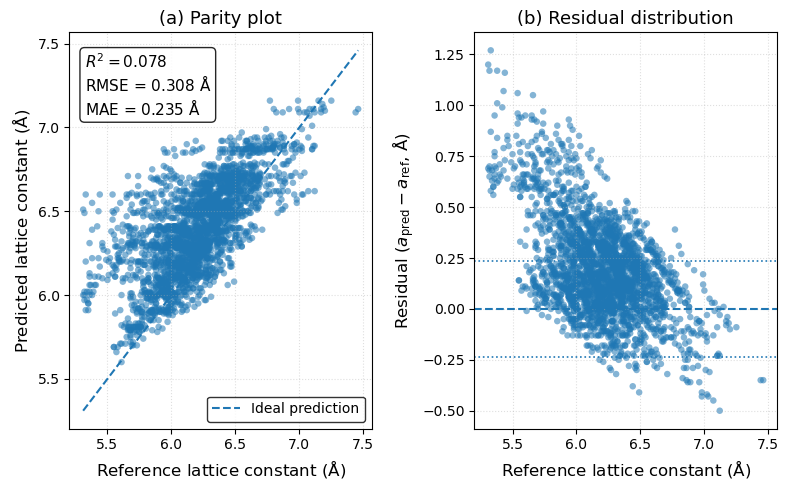

In [27]:
# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    1, 2,
    figsize=(8, 5)
)

# ------------------------------------------------------------
# (a) Parity plot
# ------------------------------------------------------------
ax[0].scatter(
    y_true,
    y_pred,
    s=22,
    alpha=0.55,
    edgecolor='none'
)

# Perfect prediction line
xmin = min(y_true.min(), y_pred.min())
xmax = max(y_true.max(), y_pred.max())

ax[0].plot(
    [xmin, xmax],
    [xmin, xmax],
    '--',
    linewidth=1.5,
    label='Ideal prediction'
)

ax[0].set_xlabel(r'Reference lattice constant ($\mathrm{\AA}$)', fontsize=12)
ax[0].set_ylabel(r'Predicted lattice constant ($\mathrm{\AA}$)', fontsize=12)

ax[0].set_title('(a) Parity plot', fontsize=13)

# Metrics
textstr = (
    rf'$R^2 = {r2:.3f}$' '\n'
    rf'RMSE = {rmse:.3f} $\mathrm{{\AA}}$' '\n'
    rf'MAE = {mae:.3f} $\mathrm{{\AA}}$'
)

ax[0].text(
    0.05,
    0.95,
    textstr,
    transform=ax[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)

ax[0].legend(
    frameon=True,
    edgecolor='black',
    loc='lower right'
)

ax[0].grid(
    True,
    linestyle=':',
    alpha=0.4
)

# ------------------------------------------------------------
# (b) Residual plot
# ------------------------------------------------------------
ax[1].scatter(
    y_true,
    residual,
    s=22,
    alpha=0.55,
    edgecolor='none'
)

ax[1].axhline(
    0,
    linestyle='--',
    linewidth=1.5
)

# ± MAE reference
ax[1].axhline(
    mae,
    linestyle=':',
    linewidth=1.2
)

ax[1].axhline(
    -mae,
    linestyle=':',
    linewidth=1.2
)

ax[1].set_xlabel(
    r'Reference lattice constant ($\mathrm{\AA}$)',
    fontsize=12
)

ax[1].set_ylabel(
    r'Residual ($a_{\mathrm{pred}}-a_{\mathrm{ref}}$, $\mathrm{\AA}$)',
    fontsize=12
)

ax[1].set_title('(b) Residual distribution', fontsize=13)

ax[1].grid(
    True,
    linestyle=':',
    alpha=0.4
)

plt.tight_layout()
plt.show()

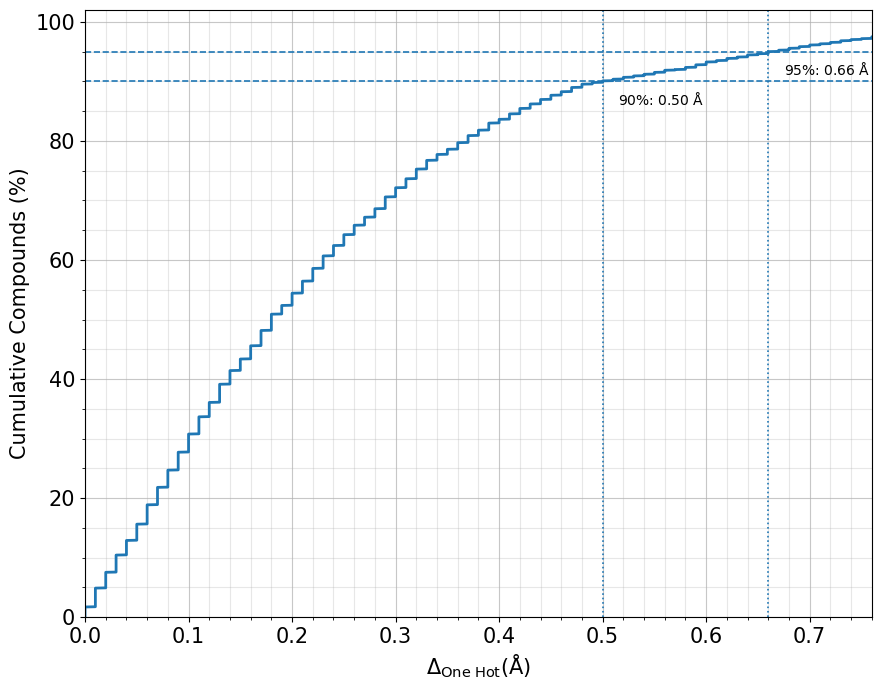

50th percentile = 0.180 Å
80th percentile = 0.370 Å
90th percentile = 0.500 Å
95th percentile = 0.660 Å


In [28]:
# ============================================================
# Cumulative absolute error distribution
# ============================================================

abs_error = np.abs(y_pred - y_true)

sorted_error = np.sort(abs_error)

cumulative_fraction = (
    np.arange(1, len(sorted_error) + 1)
    / len(sorted_error)
    * 100
)

# Percentile values
p50 = np.percentile(abs_error, 50)
p80 = np.percentile(abs_error, 80)
p90 = np.percentile(abs_error, 90)
p95 = np.percentile(abs_error, 95)

plt.figure(figsize=(9, 7))

plt.plot(
    sorted_error,
    cumulative_fraction,
    linewidth=2
)

# Important percentile lines
plt.axhline(
    90,
    linestyle='--',
    linewidth=1.2
)

plt.axhline(
    95,
    linestyle='--',
    linewidth=1.2
)

plt.axvline(
    p90,
    linestyle=':',
    linewidth=1.2
)

plt.axvline(
    p95,
    linestyle=':',
    linewidth=1.2
)

# Labels
plt.text(
    p90 + 0.015,
    86,
    rf'90%: {p90:.2f} $\mathrm{{\AA}}$',
    fontsize=10
)

plt.text(
    p95 + 0.015,
    91,
    rf'95%: {p95:.2f} $\mathrm{{\AA}}$',
    fontsize=10
)

plt.xlabel(
    r'$\Delta_{\mathrm{One\; Hot}}$($\mathrm{\AA}$)',
    fontsize=15
)

plt.ylabel(
    'Cumulative Compounds (%)',
    fontsize=15
)

# plt.title(
#     'Cumulative distribution of absolute prediction error',
#     fontsize=13
# )

plt.xlim(0, max(0.7, p95 + 0.1))
plt.ylim(0, 102)

# plt.grid(
#     True,
#     linestyle=':',
#     alpha=0.4
# )
# Customize tick size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.minorticks_on()
plt.grid(True, which='major', alpha=0.7)
plt.grid(True, which='minor', alpha=0.3)
plt.tight_layout()
#plt.savefig('Delta_OneHot.pdf')
plt.show()
print(f"50th percentile = {p50:.3f} Å")
print(f"80th percentile = {p80:.3f} Å")
print(f"90th percentile = {p90:.3f} Å")
print(f"95th percentile = {p95:.3f} Å")

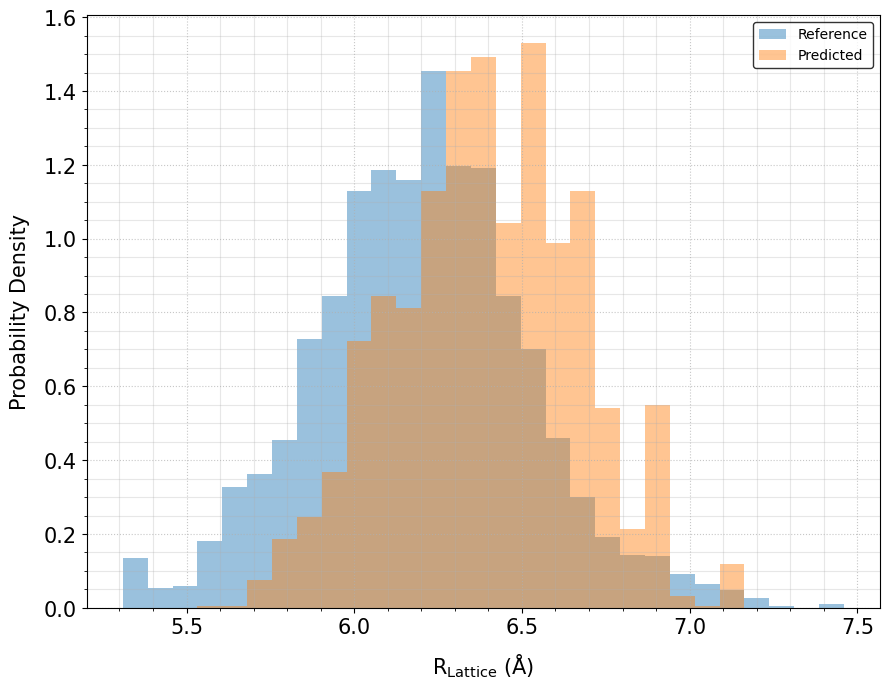

In [29]:
# ============================================================
# Distribution comparison
# ============================================================

plt.figure(figsize=(9, 7))

bins = np.linspace(
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max()),
    30
)

plt.hist(
    y_true,
    bins=bins,
    density=True,
    alpha=0.45,
    label='Reference'
)

plt.hist(
    y_pred,
    bins=bins,
    density=True,
    alpha=0.45,
    label='Predicted'
)

plt.xlabel(
    r"R$_{\mathrm{Lattice}}$ ($\mathrm{\AA}$)",
    fontsize=15,labelpad=10
)

plt.ylabel(
    'Probability Density',
    fontsize=15,labelpad=10
)

# plt.title(
#     'Reference and predicted lattice-constant distributions',
#     fontsize=13
# )

plt.legend(
    frameon=True,
    edgecolor='black'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.4
)
# Customize tick size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.minorticks_on()
plt.grid(True, which='major', alpha=0.7)
plt.grid(True, which='minor', alpha=0.3)
plt.tight_layout()
#plt.savefig('Dist_One_Hot.pdf')
plt.show()